In [1]:
# Import Libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
# Load Dataset
data=pd.read_csv("Dataset.csv")

In [3]:
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [4]:
data.shape

(17379, 17)

In [5]:
data.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


In [7]:
data.dtypes

instant        int64
dteday        object
season        object
yr            object
mnth          object
hr             int64
holiday       object
weekday        int64
workingday    object
weathersit    object
temp          object
atemp         object
hum           object
windspeed     object
casual        object
registered    object
cnt            int64
dtype: object

In [8]:
data.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


In [9]:
# Checking Missing Values 
data.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [10]:
# Checking Duplicate Records
data.duplicated().sum()

0

In [11]:
# Convert numerical columns
num_cols=['temp','atemp','hum','windspeed','casual','registered']

for i in num_cols:
    data[i]=pd.to_numeric(data[i],errors='coerce')

In [12]:
# Separate Numerical and Categorical Columns
num_features=data.select_dtypes(include=np.number)
cat_features=data.select_dtypes(include='object')

print(num_features.columns)
print(cat_features.columns)

Index(['instant', 'hr', 'weekday', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'workingday',
       'weathersit'],
      dtype='object')


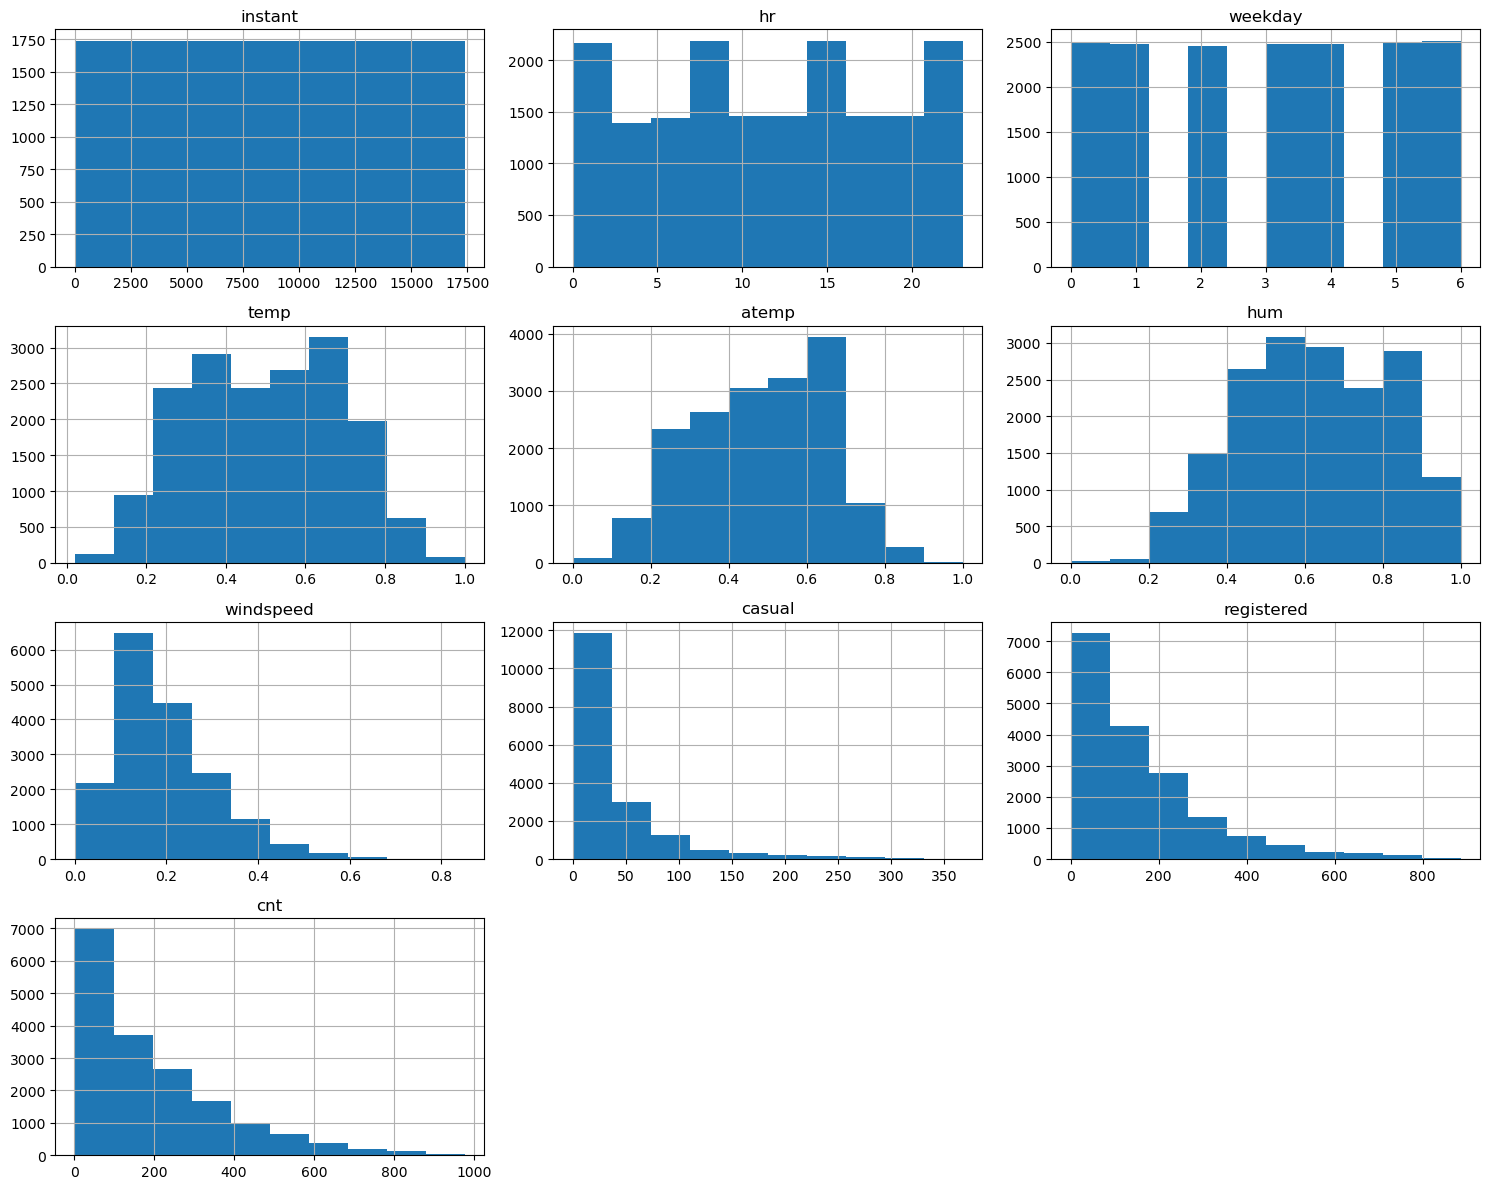

In [13]:
# Histogram
data.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

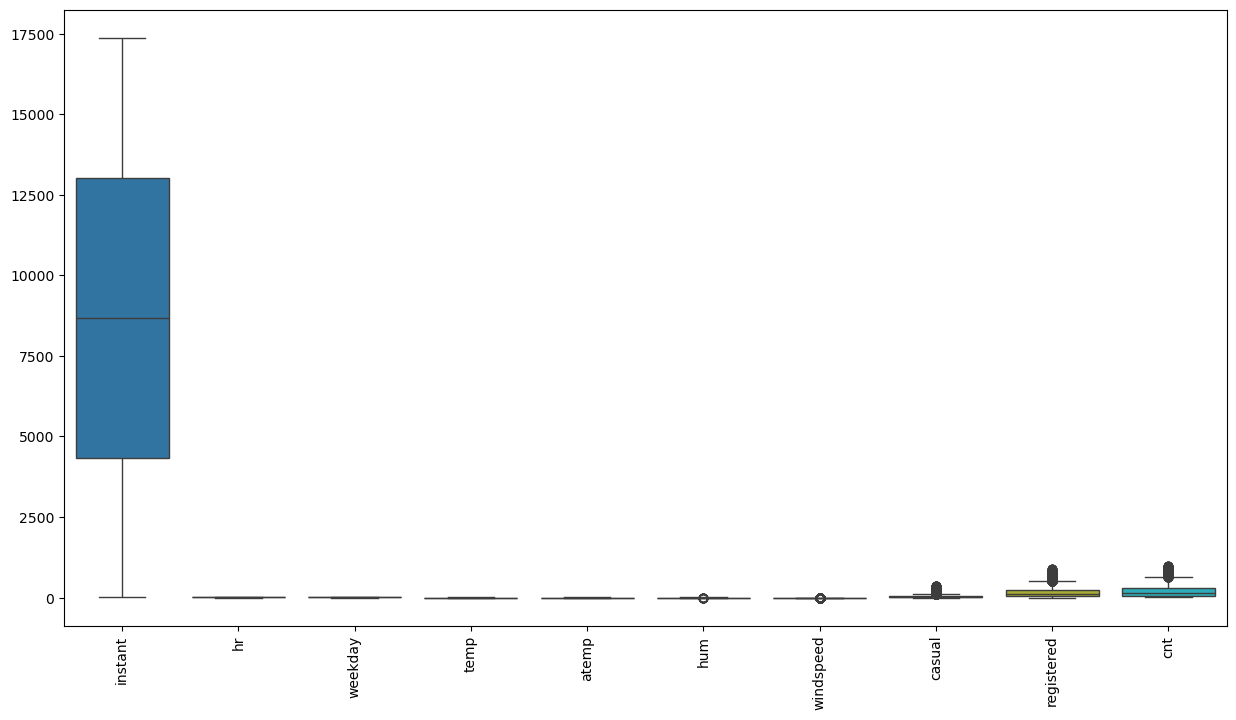

In [14]:
# Boxplot
numeric_data = data.select_dtypes(include=np.number)
plt.figure(figsize=(15,8))
sns.boxplot(data=numeric_data)
plt.xticks(rotation=90)
plt.show()

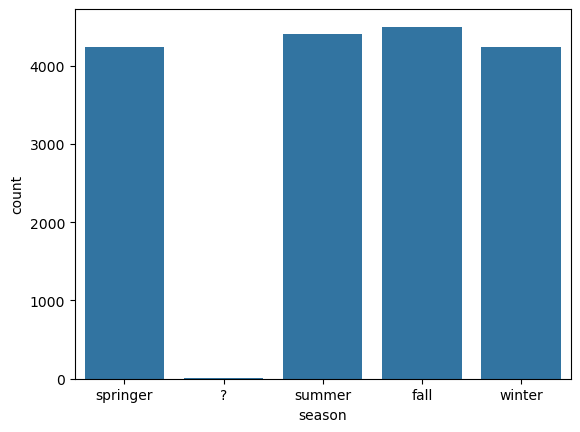

In [15]:
# Countplot for Categorical Variables
# Season
sns.countplot(x='season',data=data)
plt.show()

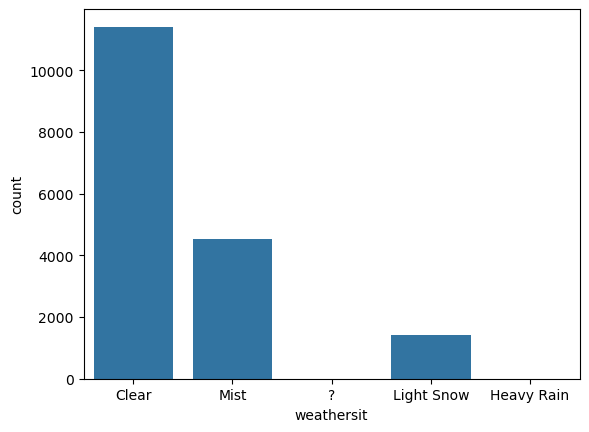

In [16]:
 # Weather Situation
sns.countplot(x='weathersit',data=data)
plt.show()

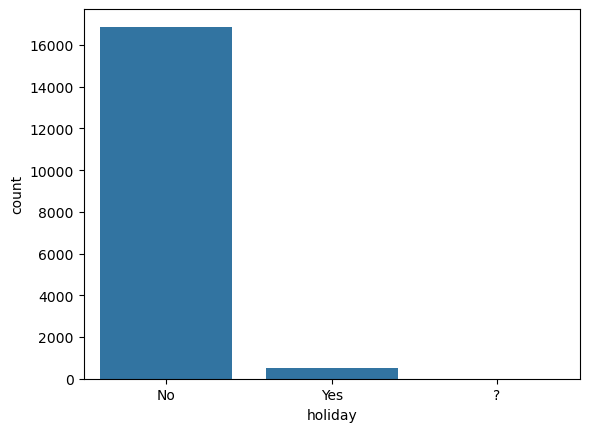

In [17]:
# Holiday
sns.countplot(x='holiday',data=data)
plt.show()

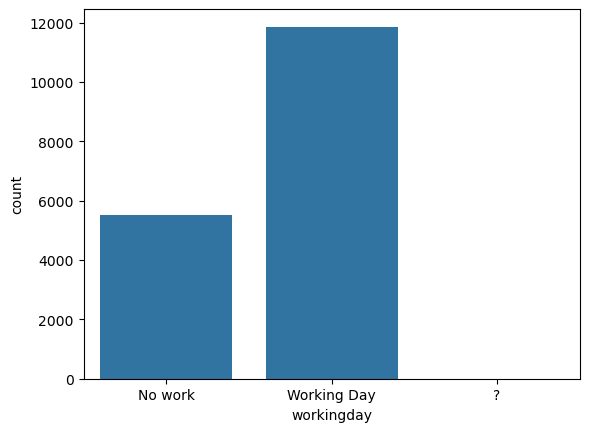

In [18]:
 # Working Day
sns.countplot(x='workingday',data=data)
plt.show()

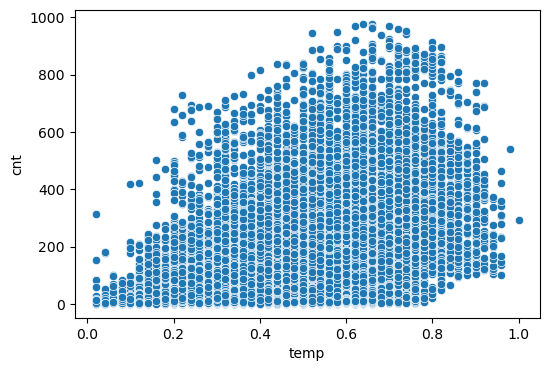

In [19]:
# Scatter plot
# Temperature vs Bike Count
plt.figure(figsize=(6,4))
sns.scatterplot(x='temp',y='cnt',data=data)
plt.show()

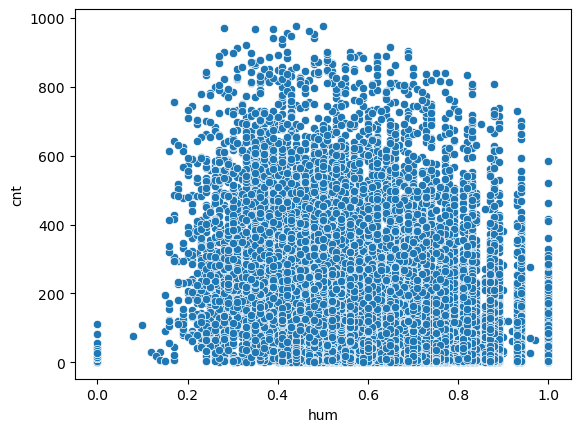

In [20]:
# Humidity vs Bike Count
sns.scatterplot(x='hum',y='cnt',data=data)
plt.show()

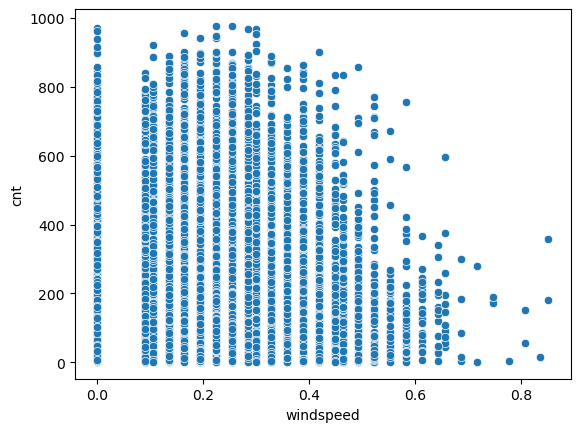

In [21]:
# Windspeed vs Bike Count
sns.scatterplot(x='windspeed',y='cnt',data=data)
plt.show()

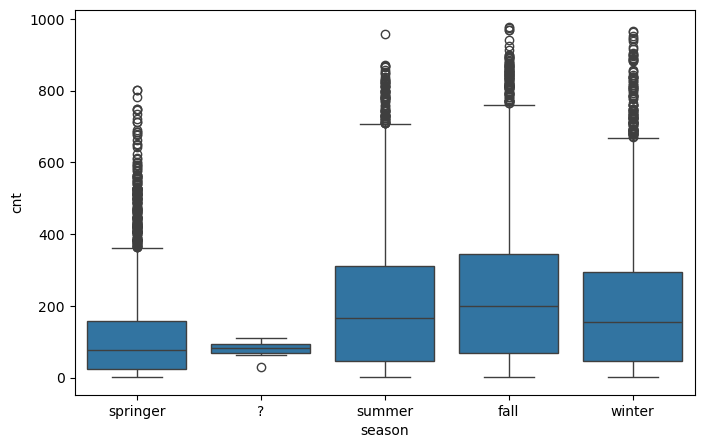

In [22]:
# Boxplots
# Season vs Bike Count
plt.figure(figsize=(8,5))
sns.boxplot(x='season',y='cnt',data=data)
plt.show()

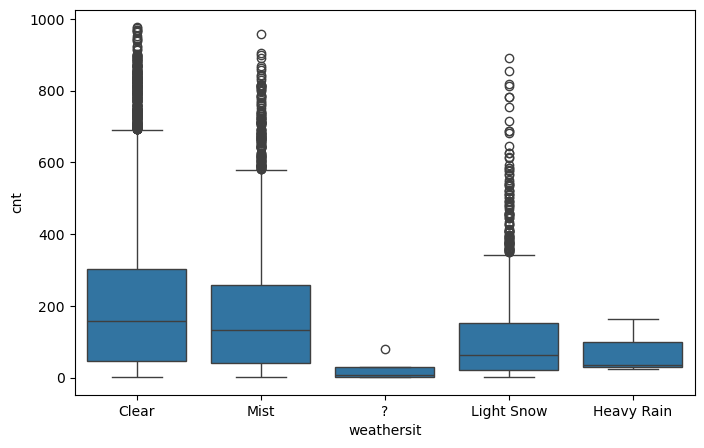

In [23]:
# Weather vs Bike Count
plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit',y='cnt',data=data)
plt.show()

In [24]:
# Correlation Analysis
num_df=data.select_dtypes(include=np.number)

In [25]:
corr=num_df.corr()
corr

,instant,hr,weekday,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,-0.004775,0.001357,0.137055,0.138325,0.009576,-0.074652,0.158296,0.282009,0.278379
hr,-0.004775,1.000000,-0.003498,0.137743,0.133943,-0.276569,0.136995,0.301202,0.374148,0.394071
weekday,0.001357,-0.003498,1.000000,-0.002015,-0.008687,-0.037201,0.011234,0.032735,0.021636,0.026900
temp,0.137055,0.137743,-0.002015,1.000000,0.987667,-0.069763,-0.022867,0.459517,0.335112,0.404557
atemp,0.138325,0.133943,-0.008687,0.987667,1.000000,-0.051891,-0.062013,0.454181,0.332499,0.400912
hum,0.009576,-0.276569,-0.037201,-0.069763,-0.051891,1.000000,-0.290141,-0.346999,-0.273841,-0.322848
windspeed,-0.074652,0.136995,0.011234,-0.022867,-0.062013,-0.290141,1.000000,0.090388,0.082410,0.093337
casual,0.158296,0.301202,0.032735,0.459517,0.454181,-0.346999,0.090388,1.000000,0.506619,0.694567
registered,0.282009,0.374148,0.021636,0.335112,0.332499,-0.273841,0.082410,0.506619,1.000000,0.972150
cnt,0.278379,0.394071,0.026900,0.404557,0.400912,-0.322848,0.093337,0.694567,0.972150,1.000000


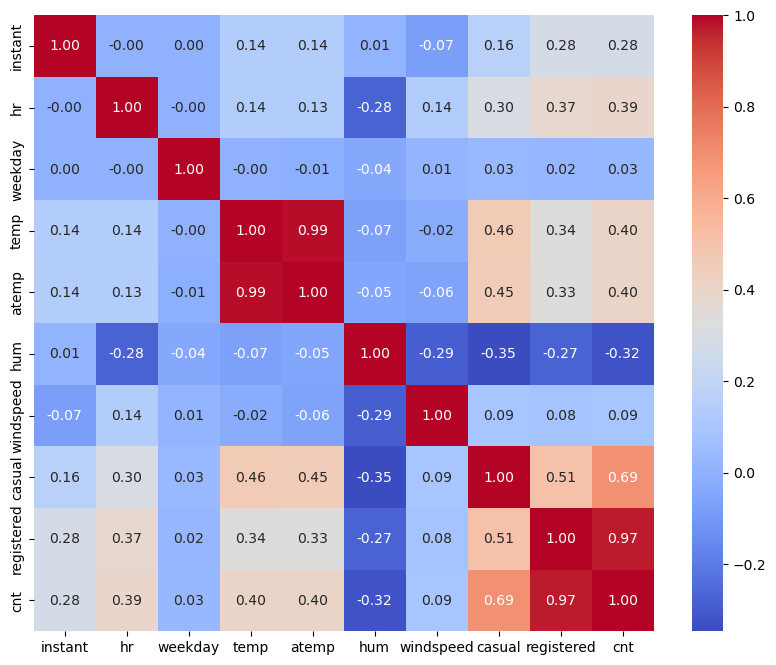

In [26]:
# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.show()

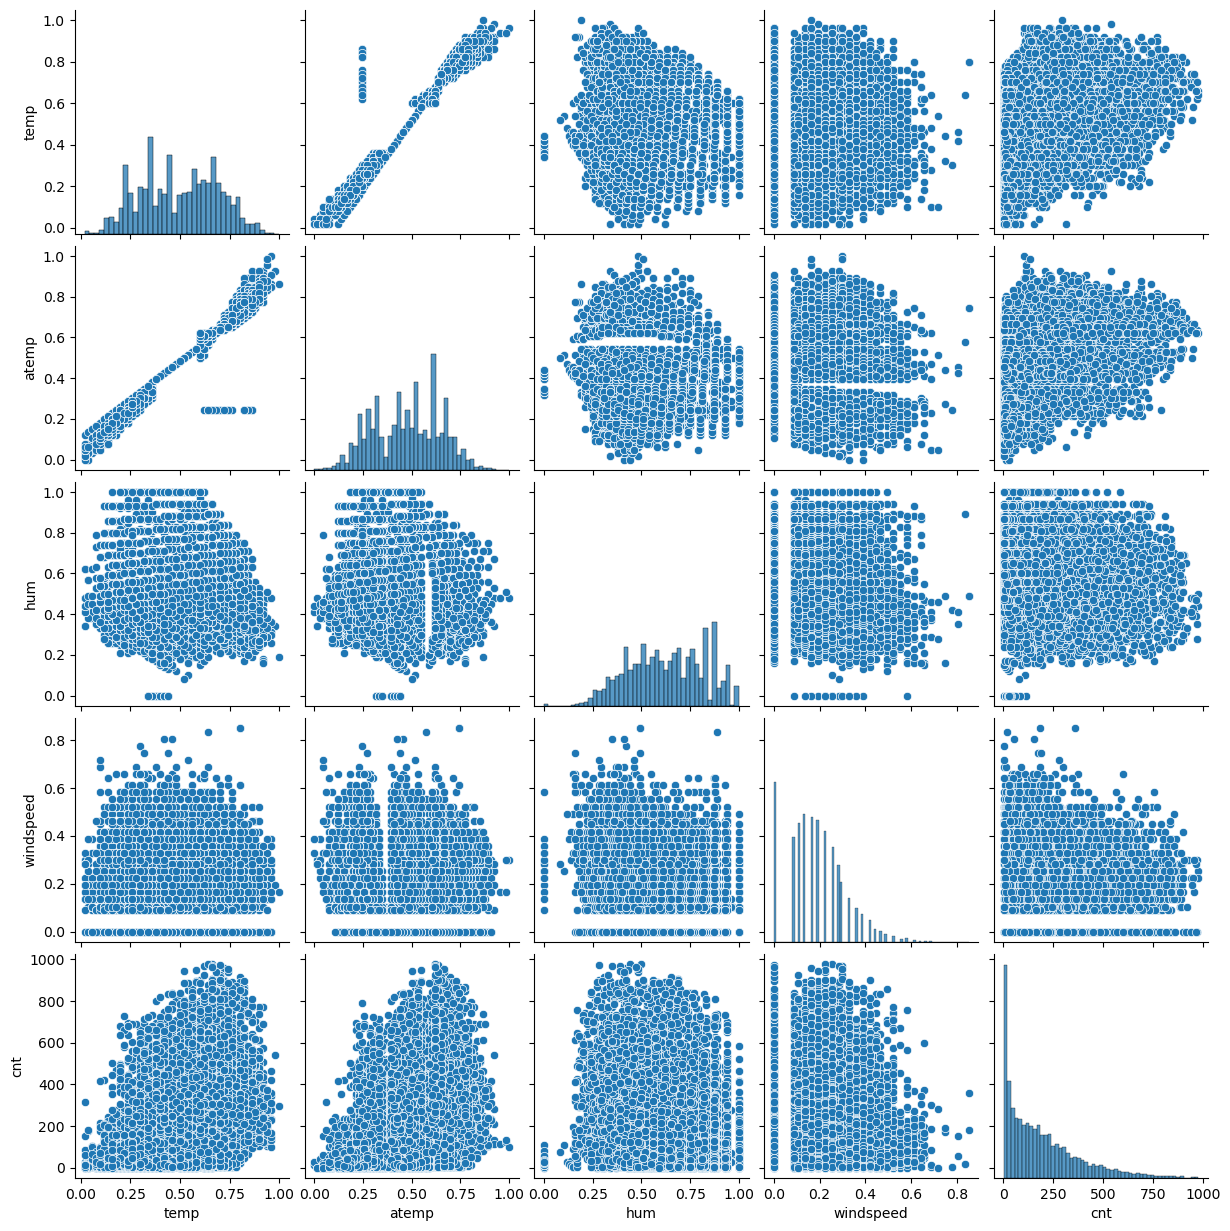

In [27]:
# Pairplot
sns.pairplot(data[['temp','atemp','hum','windspeed','cnt']])
plt.show()

In [28]:
# Outlier Detection
Q1=data['cnt'].quantile(0.25)
Q3=data['cnt'].quantile(0.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=data[(data['cnt']<lower)|(data['cnt']>upper)]

print(outliers.shape)

(505, 17)


In [29]:
# Time Series Analysis
data['dteday'] = pd.to_datetime(data['dteday'], dayfirst=True)
daily = data.groupby('dteday')['cnt'].sum()


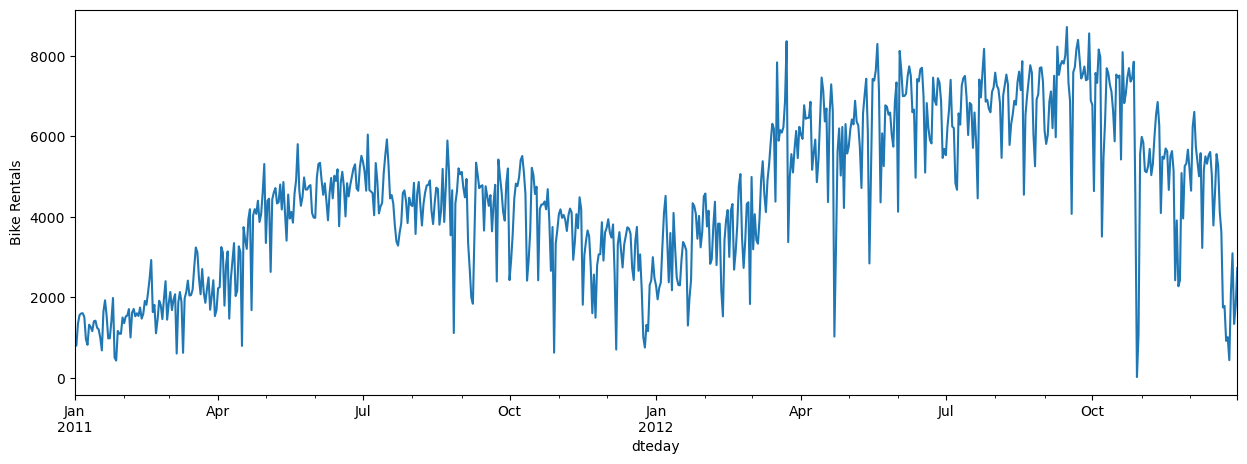

In [30]:
# daily=data.groupby('dteday')['cnt'].sum()
##Daily bike rentals
plt.figure(figsize=(15,5))
daily.plot()
plt.ylabel("Bike Rentals")
plt.show()

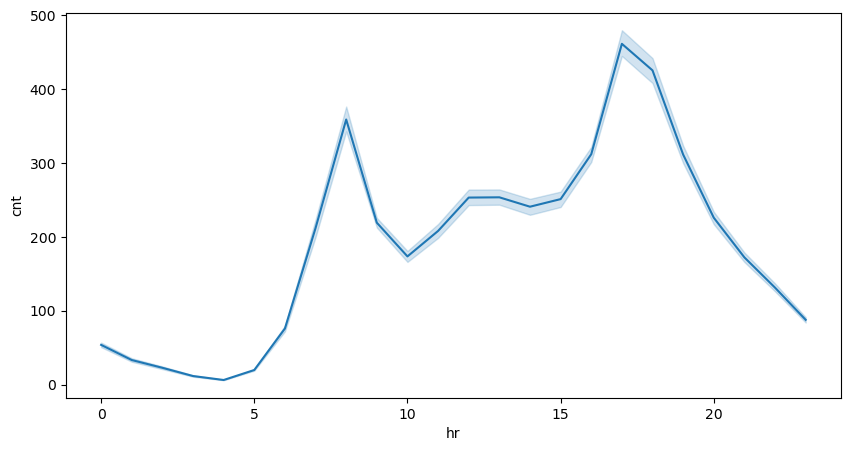

In [31]:
# Hourly Demand Pattern
plt.figure(figsize=(10,5))
sns.lineplot(x='hr',y='cnt',data=data)
plt.show()

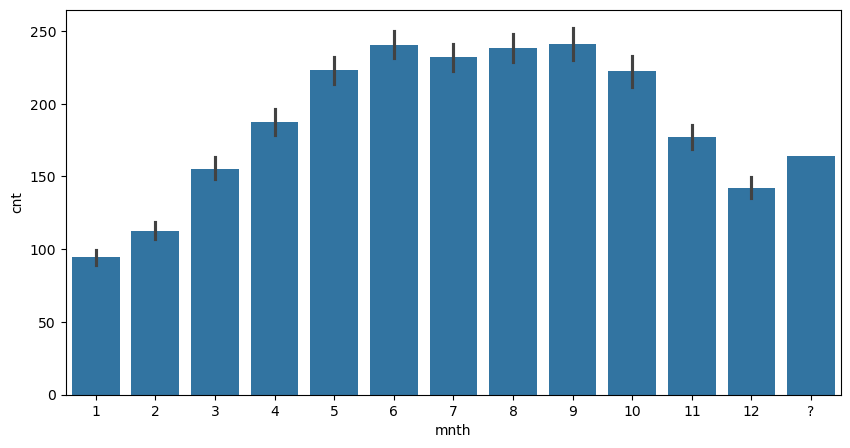

In [32]:
# Monthly Demand 
plt.figure(figsize=(10,5))
sns.barplot(x='mnth',y='cnt',data=data)
plt.show()

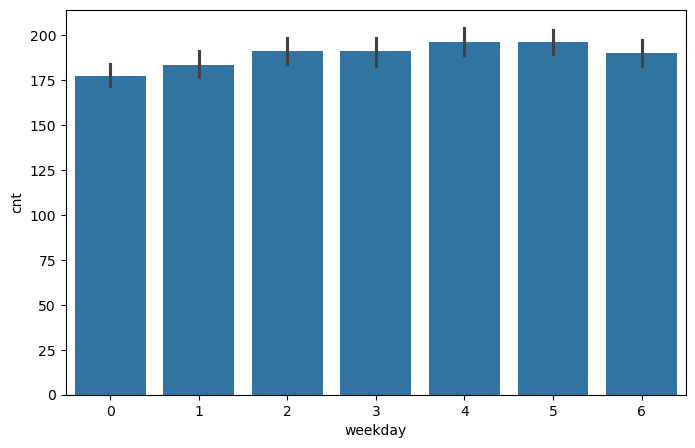

In [33]:
# Weekday Analysis
plt.figure(figsize=(8,5))
sns.barplot(x='weekday',y='cnt',data=data)
plt.show()

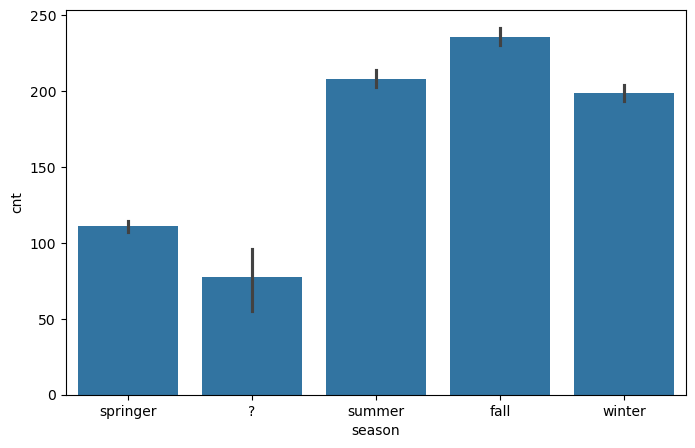

In [34]:
# Seasonal Analysis
plt.figure(figsize=(8,5))
sns.barplot(x='season',y='cnt',data=data)
plt.show()

##  Model Building

In [36]:
# Import Libraries 
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [37]:
# Target variable
y = data['cnt']

# Drop target and date column
X = data.drop(['cnt', 'dteday'], axis=1)

In [38]:
# Convert categorical columns into dummy variables
X = pd.get_dummies(X, drop_first=True)

In [39]:
# Fill missing values with median
X = X.fillna(X.median(numeric_only=True))

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 2.Model Evaluation 

## Decision Tree 

In [43]:

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [44]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

In [45]:
print("Decision Tree")
print("MAE =", dt_mae)
print("MSE =", dt_mse)
print("RMSE =", dt_rmse)
print("R2 Score =", dt_r2)

Decision Tree
MAE = 2.252013808975834
MSE = 26.60644418872267
RMSE = 5.158143482758372
R2 Score = 0.9991597631906304


## Random Forest 

In [47]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [48]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

In [49]:
print("Random Forest")
print("MAE =", rf_mae)
print("MSE =", rf_mse)
print("RMSE =", rf_rmse)
print("R2 Score =", rf_r2)

Random Forest
MAE = 0.9729861910241655
MSE = 7.704623475258919
RMSE = 2.775720352495712
R2 Score = 0.9997566864553441


## Gradient Boosting 

In [51]:

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

In [52]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

In [53]:
print("Gradient Boosting")
print("MAE =", gb_mae)
print("MSE =", gb_mse)
print("RMSE =", gb_rmse)
print("R2 Score =", gb_r2)

Gradient Boosting
MAE = 3.234748560146305
MSE = 27.3587129436944
RMSE = 5.230555701232365
R2 Score = 0.999136006393443


## Linear Regression

In [55]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [56]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

In [57]:
print("Linear Regression")
print("MAE =", lr_mae)
print("MSE =", lr_mse)
print("RMSE =", lr_rmse)
print("R2 Score =", lr_r2)

Linear Regression
MAE = 0.014844179073797226
MSE = 0.00038815207074177735
RMSE = 0.01970157533655056
R2 Score = 0.9999999877420802


## XGBoost Regressor

In [59]:
xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [60]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred)

In [61]:
print("XGBoost")
print("MAE =", xgb_mae)
print("MSE =", xgb_mse)
print("RMSE =", xgb_rmse)
print("R2 Score =", xgb_r2)

XGBoost
MAE = 2.066766843096845
MSE = 17.241372775397732
RMSE = 4.152273205775089
R2 Score = 0.9994555115699768


# 3.Hyperparameter Tuning 

## Decision Tree

In [64]:
dt_params = {
    'max_depth': [5,10,15],
    'min_samples_split': [2,5,10]
}

In [65]:
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

print("Best Parameters:", dt_grid.best_params_)

Best Parameters: {'max_depth': 15, 'min_samples_split': 5}


## Random Forest

In [67]:
rf_params = {
    'n_estimators': [100],
    'max_depth': [10,],
    'min_samples_split': [2,]
}

In [68]:
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring='r2'
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)


Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


## Gradient Boosting

In [70]:
gb_params = {
    'n_estimators': [100,200],
    'learning_rate': [0.01,0.1],
    'max_depth': [3,5]
}

In [71]:
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


## XGBoost

In [73]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

In [74]:
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


# 4.Re-evaluate Tuned Models 


## Tuned Decision Tree

In [77]:
best_dt = dt_grid.best_estimator_

dt_pred_tuned = best_dt.predict(X_test)

dt_rmse_tuned = np.sqrt(mean_squared_error(y_test, dt_pred_tuned))
dt_r2_tuned = r2_score(y_test, dt_pred_tuned)

## Tuned Random Forest

In [79]:
best_rf = rf_grid.best_estimator_

rf_pred_tuned = best_rf.predict(X_test)

rf_rmse_tuned = np.sqrt(mean_squared_error(y_test, rf_pred_tuned))
rf_r2_tuned = r2_score(y_test, rf_pred_tuned)

## Tuned Gradient Boosting

In [81]:
best_rf = rf_grid.best_estimator_

rf_pred_tuned = best_rf.predict(X_test)

rf_rmse_tuned = np.sqrt(mean_squared_error(y_test, rf_pred_tuned))
rf_r2_tuned = r2_score(y_test, rf_pred_tuned)


## Tuned XGBoost Model

In [83]:
best_xgb = xgb_grid.best_estimator_

xgb_pred_tuned = best_xgb.predict(X_test)

xgb_rmse_tuned = np.sqrt(mean_squared_error(y_test, xgb_pred_tuned))
xgb_r2_tuned = r2_score(y_test, xgb_pred_tuned)

#### Visualization Plots of all models

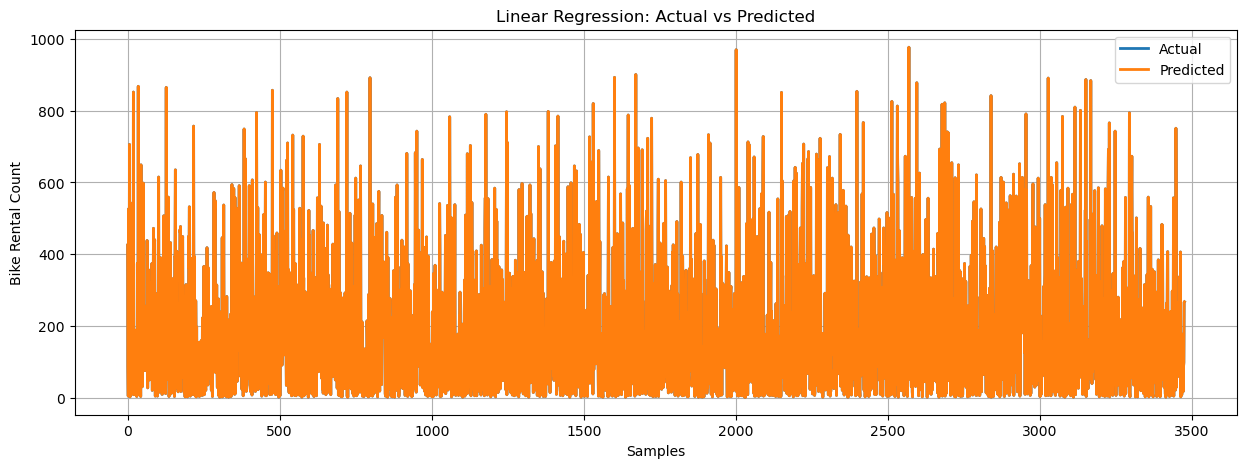

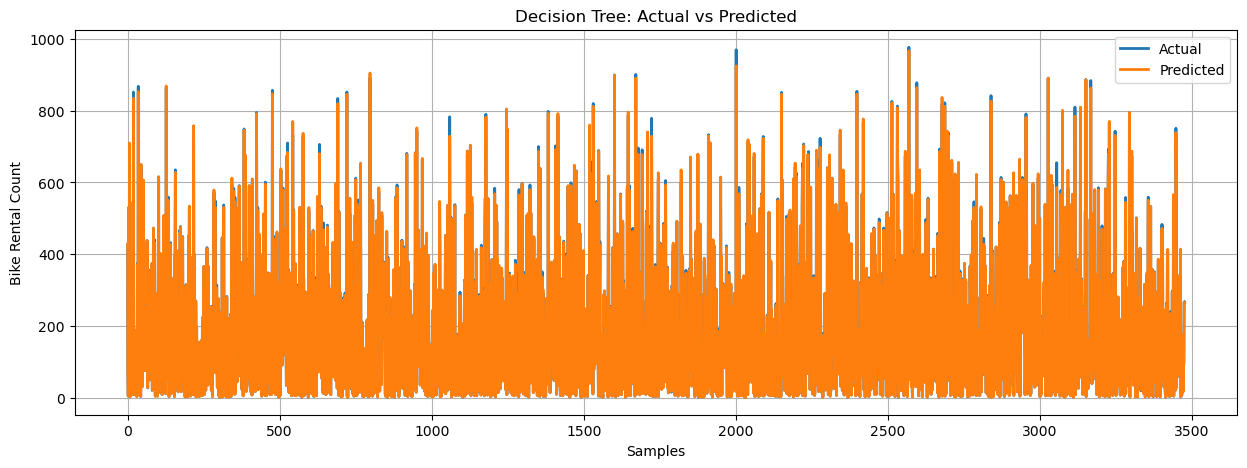

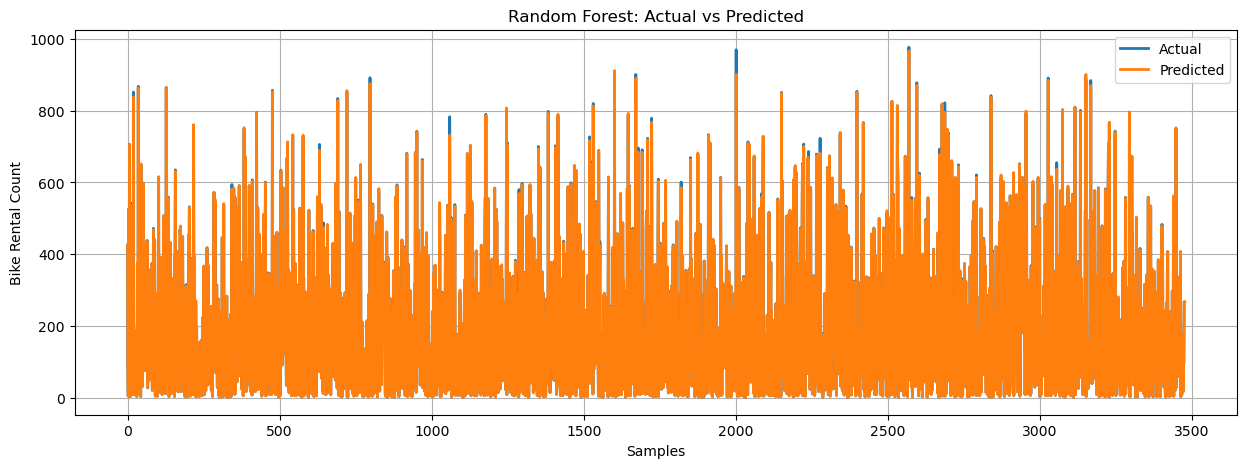

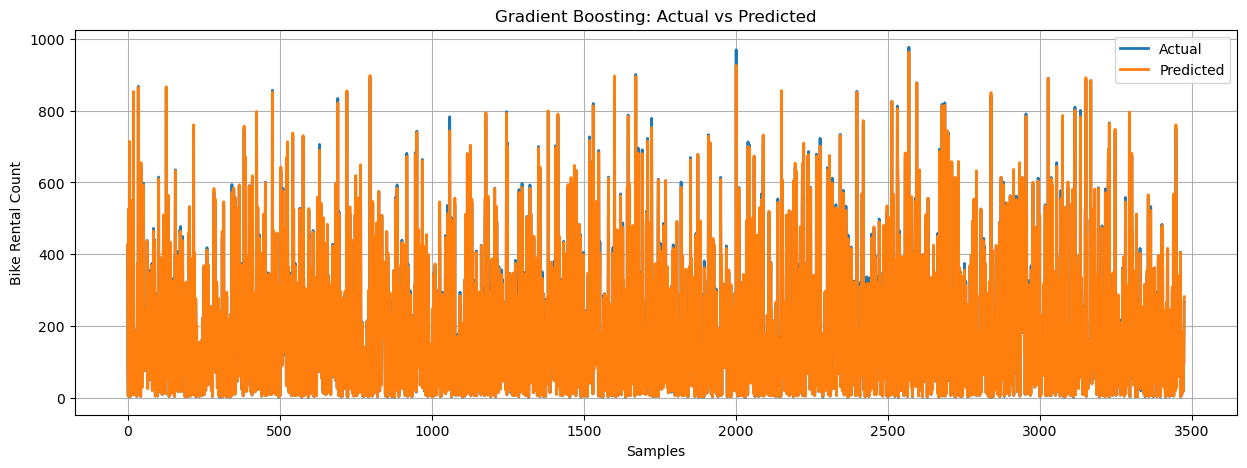

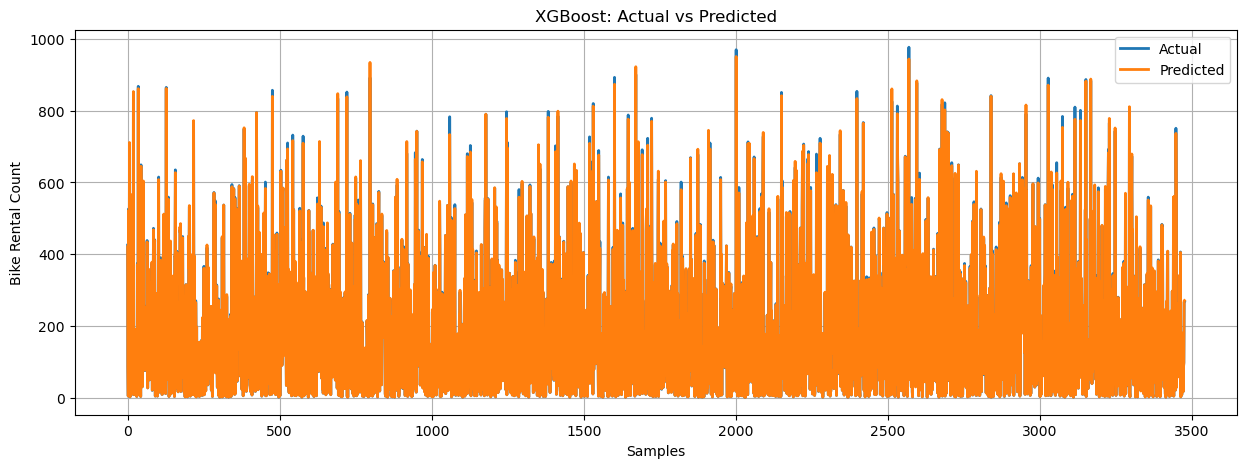

In [85]:
import matplotlib.pyplot as plt

# ACTUAL vs PREDICTED PLOTS

models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    plt.figure(figsize=(15, 5))

    plt.plot(y_test.values, label="Actual", linewidth=2)
    plt.plot(pred, label="Predicted", linewidth=2)

    plt.title(f"{name}: Actual vs Predicted")
    plt.xlabel("Samples")
    plt.ylabel("Bike Rental Count")
    plt.legend()
    plt.grid(True)

    plt.show()

# 5.Comparing all Models

In [87]:

# MODEL COMPARISON

print("\n" + "="*90)
print("FINAL RESULTS - ALL MODELS COMPARISON")
print("="*90)

results = {
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost'
    ],

    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae,
        gb_mae,
        xgb_mae
    ],

    'MSE': [
        lr_mse,
        dt_mse,
        rf_mse,
        gb_mse,
        xgb_mse
    ],

    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse
    ],

    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ]
}

results_df = pd.DataFrame(results)

# Sort by MAE (Lower is better)
results_df = results_df.sort_values(by='MAE').reset_index(drop=True)

print("\n")
print(results_df.to_string(index=False))



FINAL RESULTS - ALL MODELS COMPARISON


            Model      MAE       MSE     RMSE  R2 Score
Linear Regression 0.014844  0.000388 0.019702  1.000000
    Random Forest 0.972986  7.704623 2.775720  0.999757
          XGBoost 2.066767 17.241373 4.152273  0.999456
    Decision Tree 2.252014 26.606444 5.158143  0.999160
Gradient Boosting 3.234749 27.358713 5.230556  0.999136


In [88]:
# BEST MODEL

best_model = results_df.iloc[0]

print("\n" + "="*90)
print(f"🏆 BEST MODEL : {best_model['Model']}")
print(f"   MAE       : {best_model['MAE']:.2f}")
print(f"   MSE       : {best_model['MSE']:.2f}")
print(f"   RMSE      : {best_model['RMSE']:.2f}")
print(f"   R² Score  : {best_model['R2 Score']:.4f}")
print("="*90)



🏆 BEST MODEL : Linear Regression
   MAE       : 0.01
   MSE       : 0.00
   RMSE      : 0.02
   R² Score  : 1.0000


In [89]:
# MODEL RANKING 

results_df = results_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("MODEL RANKING BASED ON R² SCORE\n")

medals = ['🥇', '🥈', '🥉', '🏅', '🎖️']

for idx, row in results_df.iterrows():
    print(
        f"{medals[idx]} {idx+1}. "
        f"{row['Model']:<20}"
        f"MAE: {row['MAE']:10.2f}   "
        f"MSE: {row['MSE']:12.2f}   "
        f"RMSE: {row['RMSE']:10.2f}   "
        f"R²: {row['R2 Score']:.4f}"
    )

print("="*90)


MODEL RANKING BASED ON R² SCORE

🥇 1. Linear Regression   MAE:       0.01   MSE:         0.00   RMSE:       0.02   R²: 1.0000
🥈 2. Random Forest       MAE:       0.97   MSE:         7.70   RMSE:       2.78   R²: 0.9998
🥉 3. XGBoost             MAE:       2.07   MSE:        17.24   RMSE:       4.15   R²: 0.9995
🏅 4. Decision Tree       MAE:       2.25   MSE:        26.61   RMSE:       5.16   R²: 0.9992
🎖️ 5. Gradient Boosting   MAE:       3.23   MSE:        27.36   RMSE:       5.23   R²: 0.9991


## Conclusion

• Five regression models, namely Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost, were developed and evaluated for predicting bike rental demand.

• Among all the models, Linear Regression performed better than Random Forest, XGBoost, Decision Tree, and Gradient Boosting Regression.

• Therefore, Linear Regression is selected as the best model for predicting bike rental demand.

• Linear Regression is the best model because it has the highest R² score and the lowest MAE, MSE, and RMSE values among all the models.

• Hence, Linear Regression can predict bike rental demand more accurately and efficiently than the other models.

# Model Deployment

In [92]:
import joblib


In [93]:
# Save the best model
joblib.dump(lr_model, 'bike_rental_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [94]:
# Load the saved model
loaded_model = joblib.load('bike_rental_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!
